<a href="https://colab.research.google.com/github/Abdil2146/tugas-data-science-kelompok/blob/main/Tugas_Final_FSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

import joblib

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


In [4]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 1025
Jumlah Kolom : 14


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
print("Jumlah Data Duplikat :", df.duplicated().sum())

Jumlah Data Duplikat : 723


In [10]:
df = df.drop_duplicates()

print(df.shape)

(302, 14)


In [11]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0
878,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


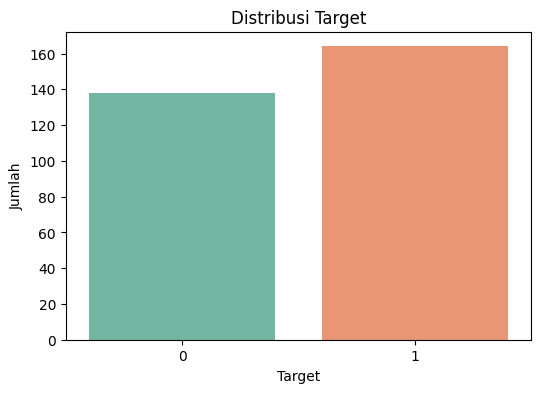

In [12]:
# ==========================================
# DISTRIBUSI TARGET
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df, palette='Set2')

plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Jumlah")

plt.show()

In [13]:
(df['target'].value_counts(normalize=True)*100).round(2)

,proportion
target,
1,54.3
0,45.7


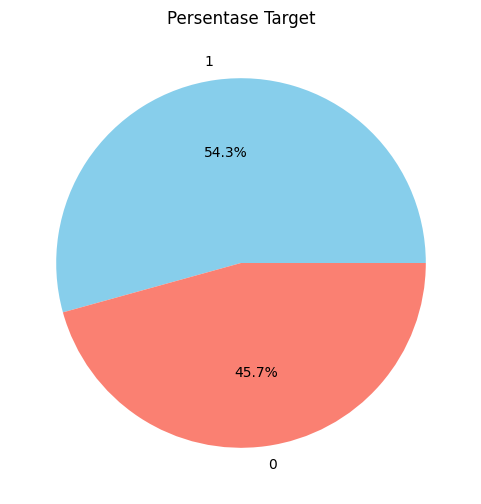

In [14]:
plt.figure(figsize=(6,6))

df['target'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','salmon']
)

plt.ylabel("")
plt.title("Persentase Target")

plt.show()

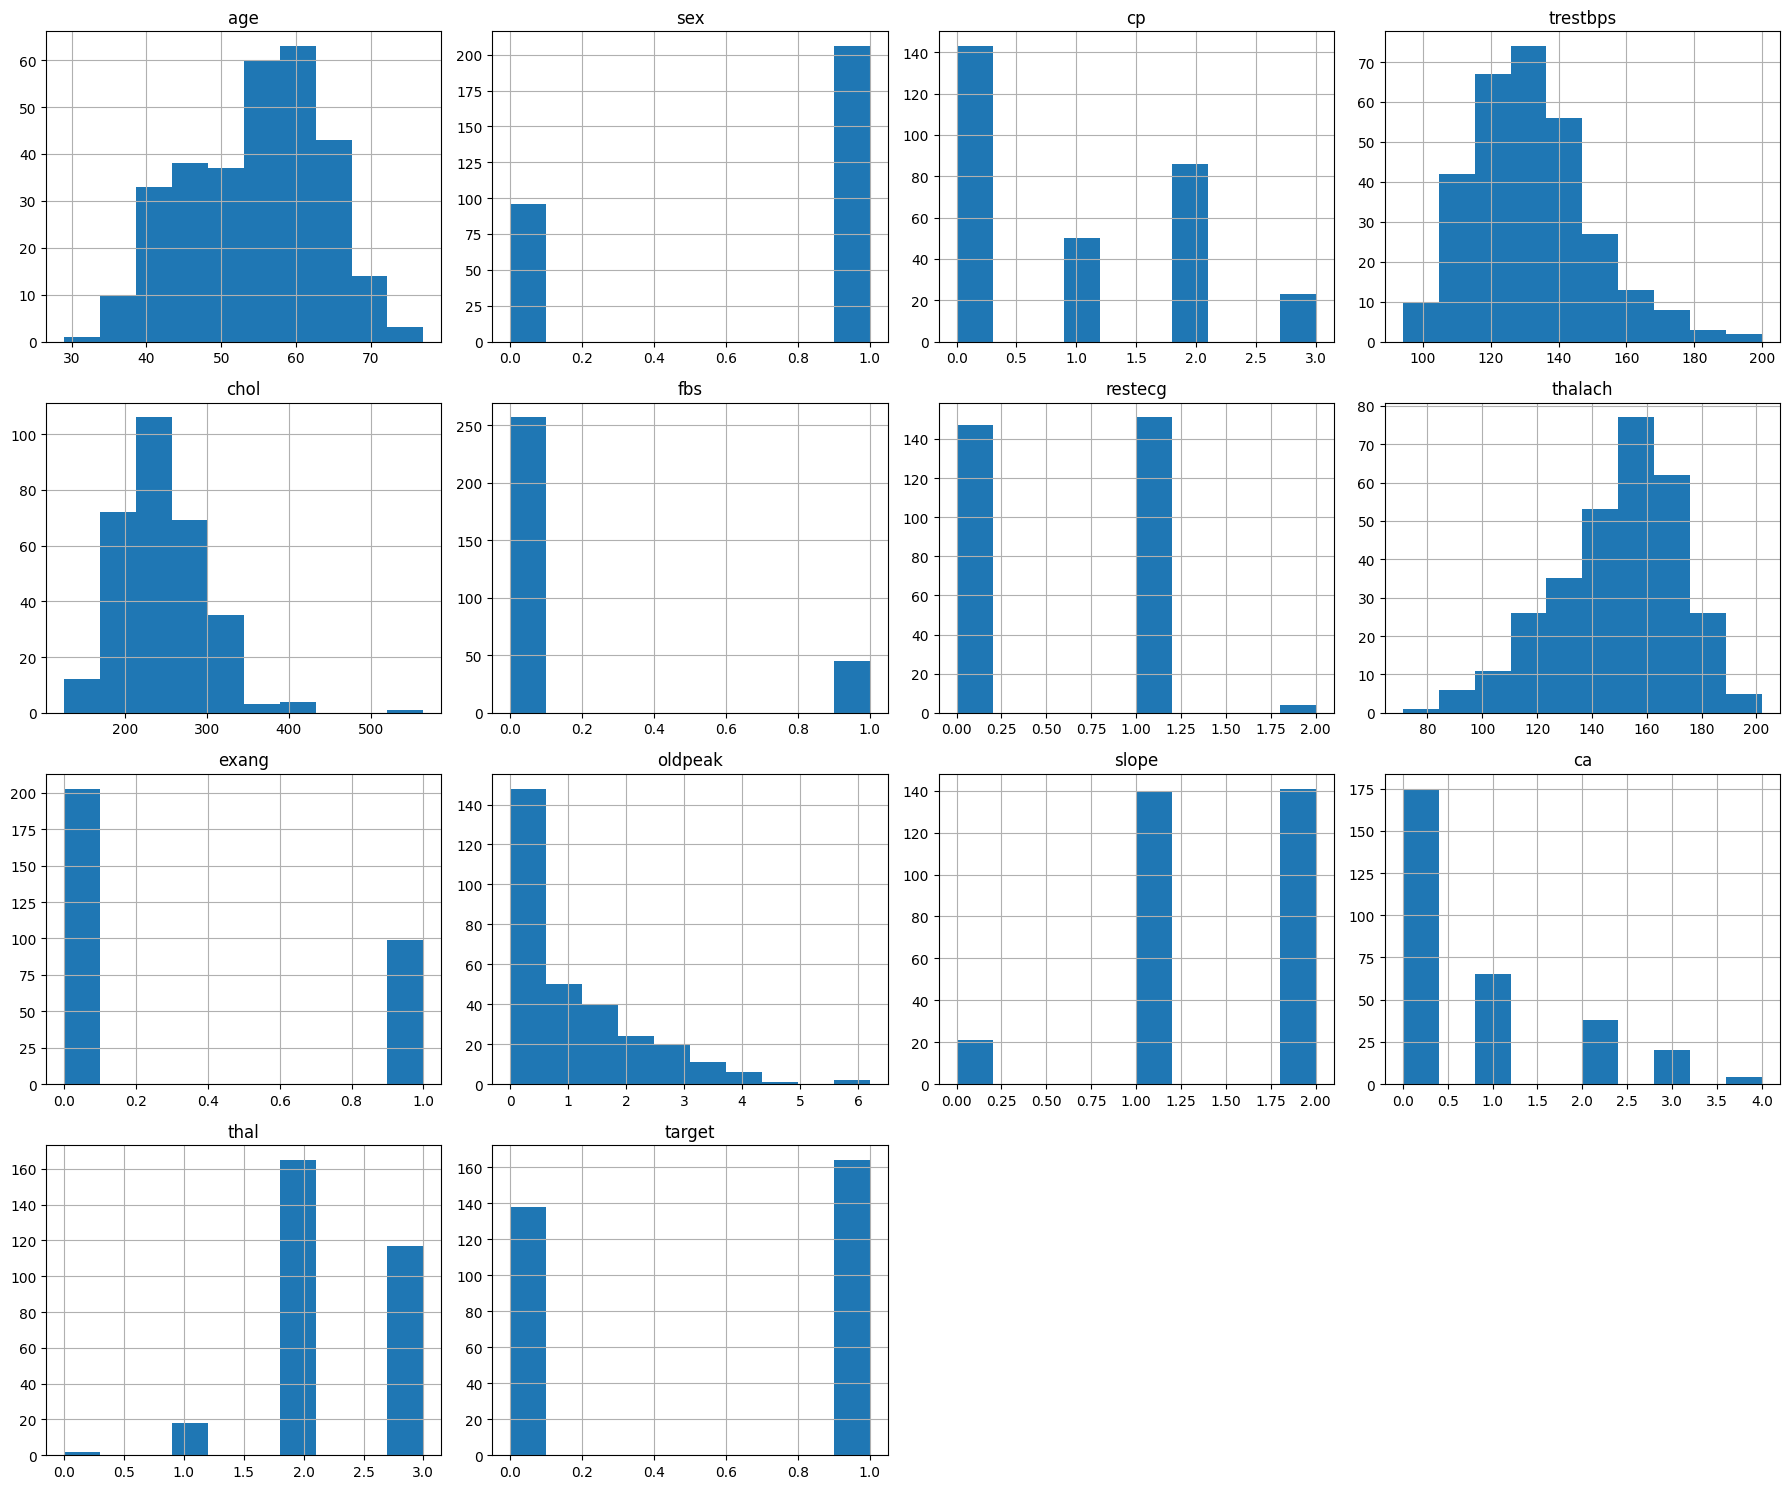

In [15]:
df.hist(figsize=(18,15))

plt.tight_layout()

plt.show()

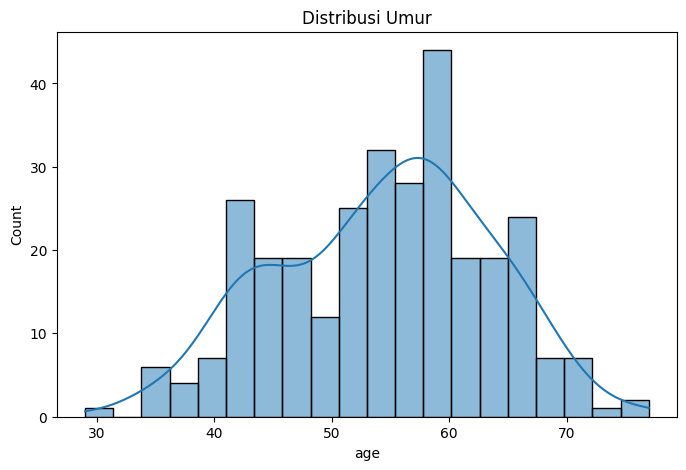

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Distribusi Umur")

plt.show()

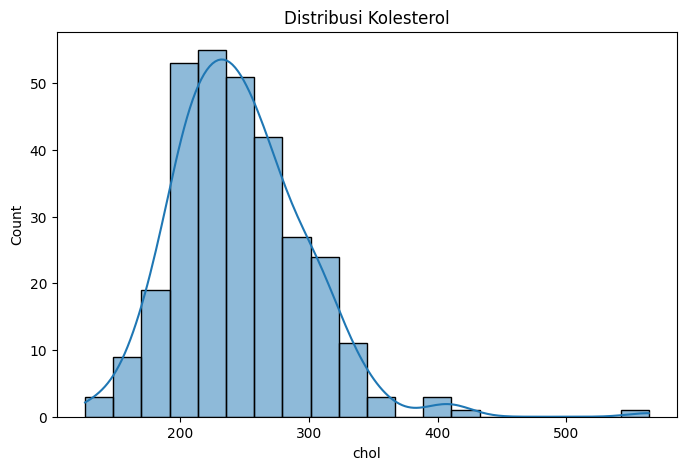

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['chol'], bins=20, kde=True)

plt.title("Distribusi Kolesterol")

plt.show()

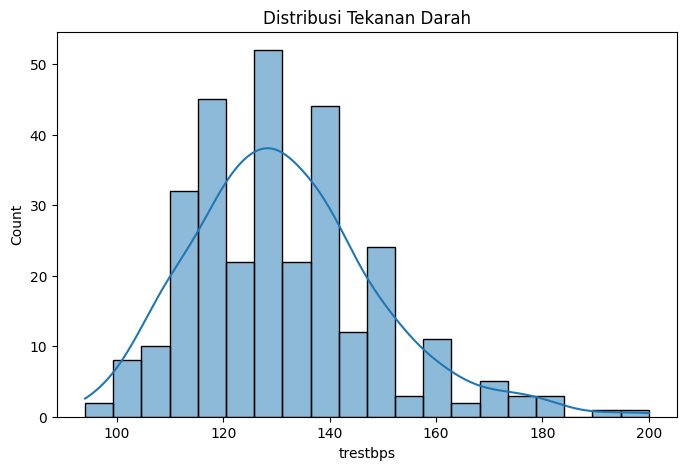

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['trestbps'], bins=20, kde=True)

plt.title("Distribusi Tekanan Darah")

plt.show()

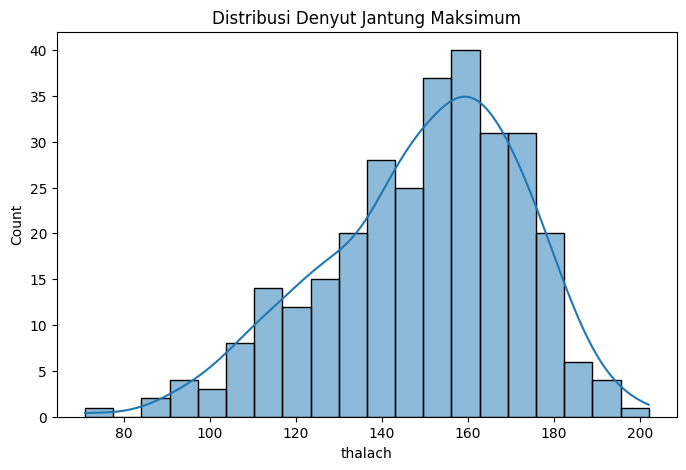

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df['thalach'], bins=20, kde=True)

plt.title("Distribusi Denyut Jantung Maksimum")

plt.show()

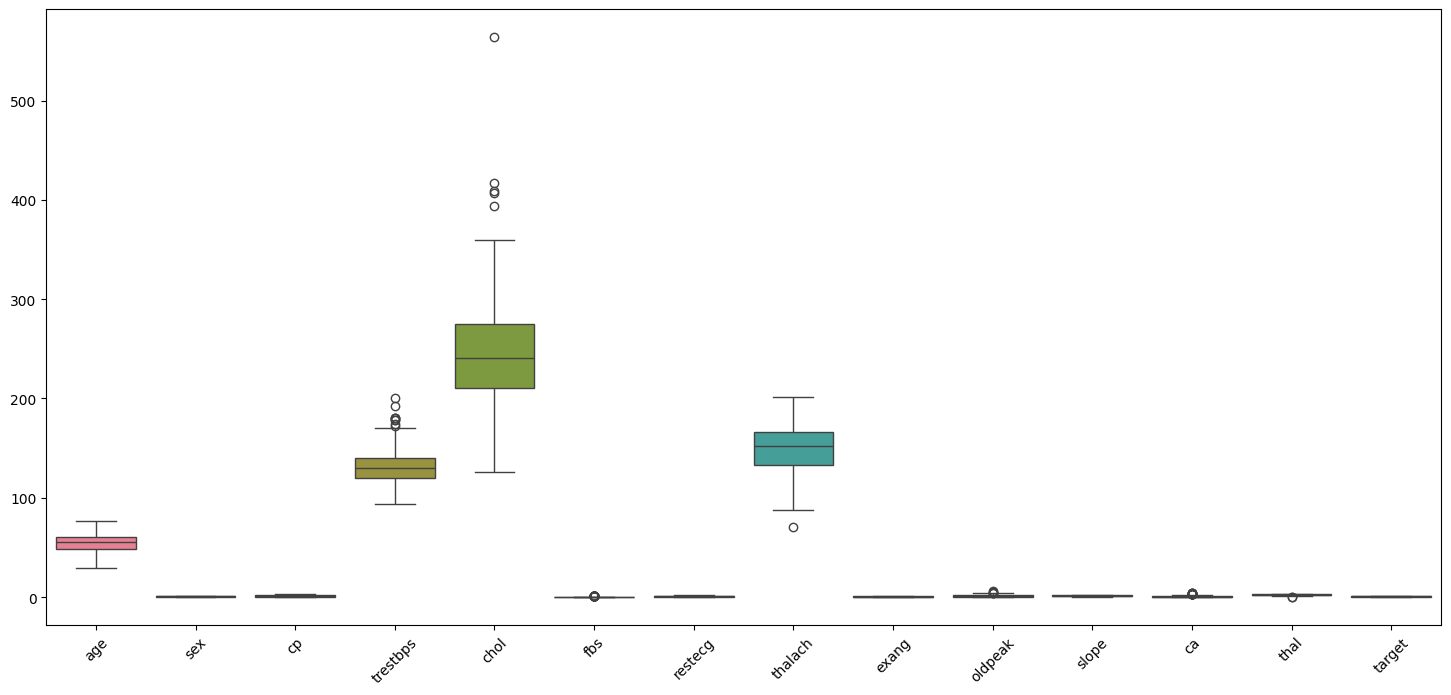

In [20]:
plt.figure(figsize=(18,8))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.show()

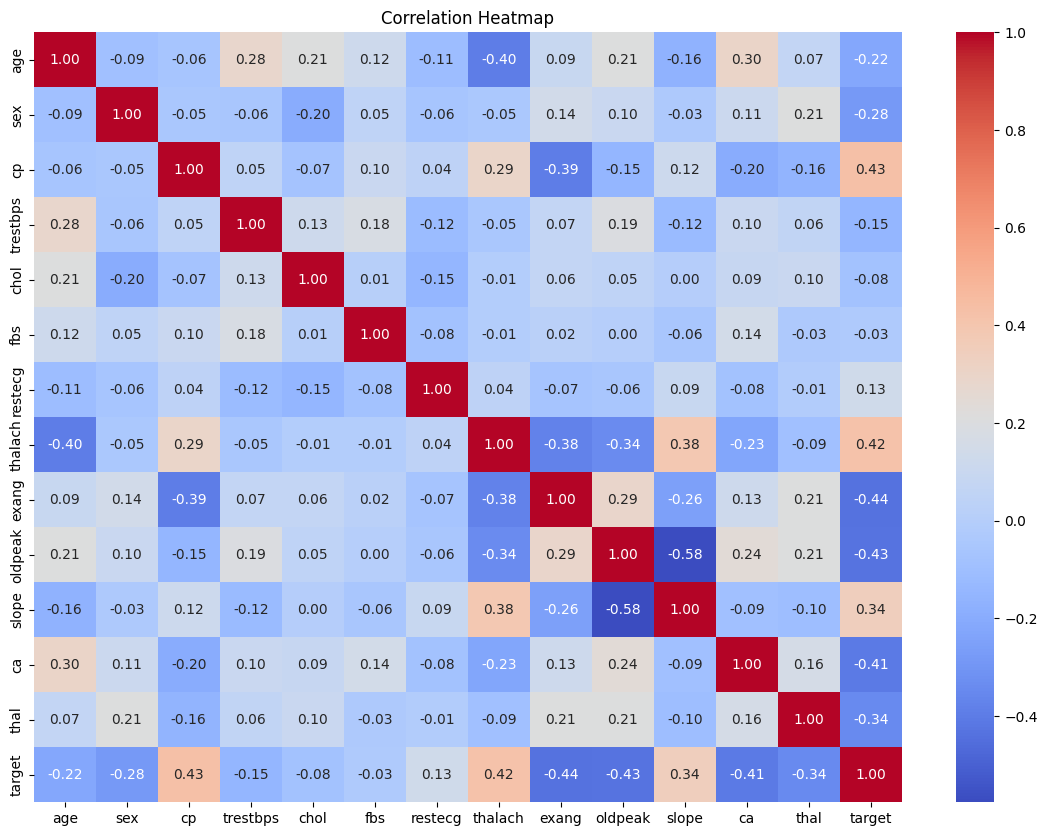

In [21]:
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

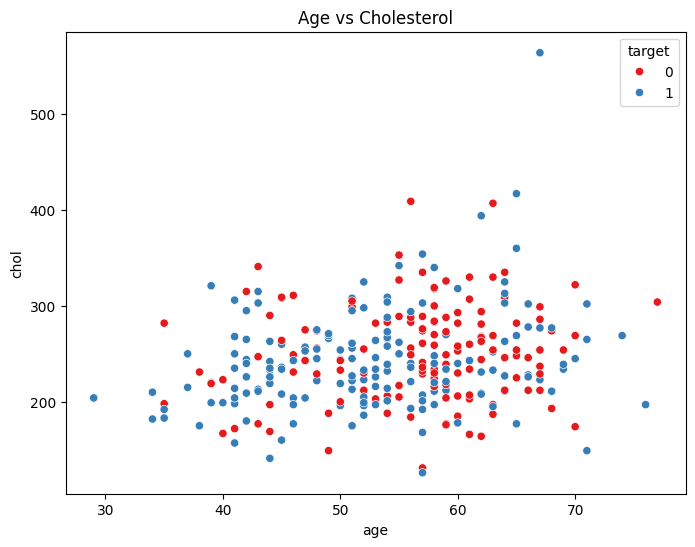

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='age',
    y='chol',
    hue='target',
    palette='Set1'
)

plt.title("Age vs Cholesterol")

plt.show()

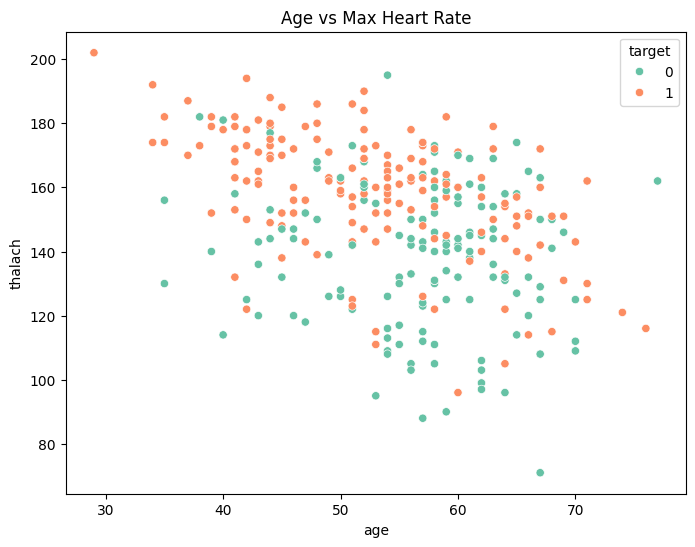

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='age',
    y='thalach',
    hue='target',
    palette='Set2'
)

plt.title("Age vs Max Heart Rate")

plt.show()

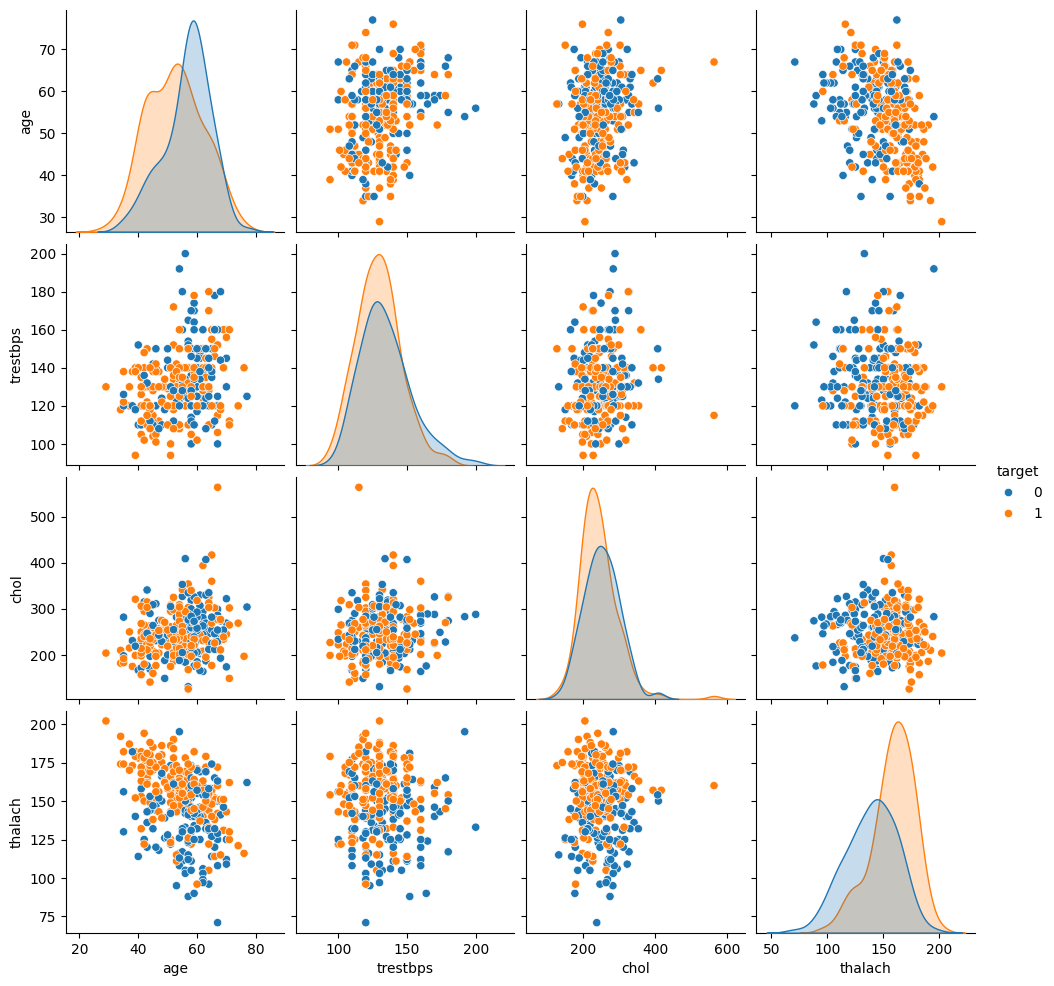

In [24]:
sns.pairplot(
    df[['age','trestbps','chol','thalach','target']],
    hue='target'
)

plt.show()

In [25]:
# ==========================================
# MEMISAHKAN FITUR DAN TARGET
# ==========================================

X = df.drop("target", axis=1)

y = df["target"]

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (302, 13)
Shape y : (302,)


In [26]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

Training : (241, 13)
Testing  : (61, 13)


In [27]:
# ==========================================
# STANDARD SCALER
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [28]:
# ==========================================
# RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [29]:
# ==========================================
# PREDIKSI
# ==========================================

y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2),"%")

Accuracy : 75.41 %


In [31]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Precision :", precision_score(y_test,y_pred))
print("Recall    :", recall_score(y_test,y_pred))
print("F1 Score  :", f1_score(y_test,y_pred))

Precision : 0.7647058823529411
Recall    : 0.7878787878787878
F1 Score  : 0.7761194029850746


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



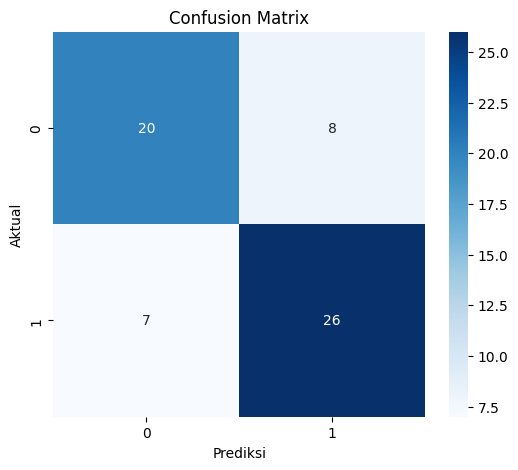

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Prediksi")

plt.ylabel("Aktual")

plt.title("Confusion Matrix")

plt.show()

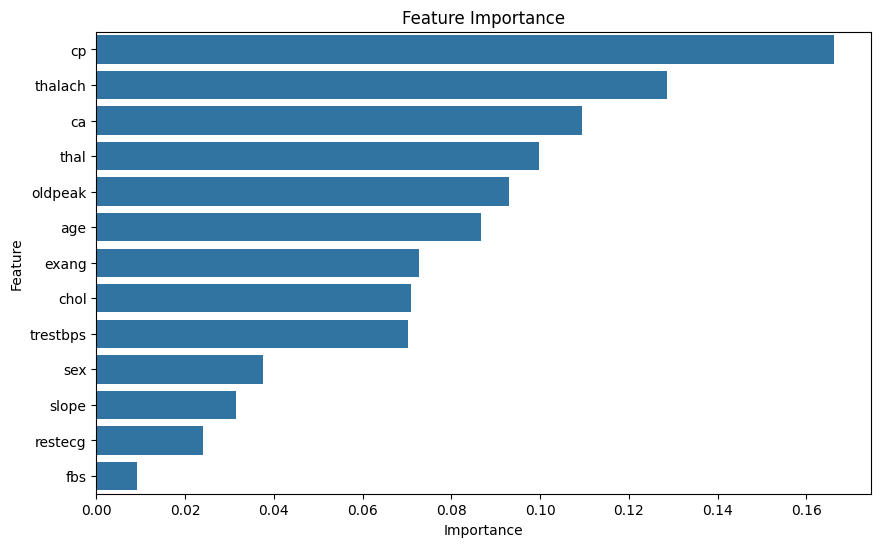

In [34]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [35]:
import joblib

joblib.dump(model, "heart_model.pkl")

print("Model berhasil disimpan.")

Model berhasil disimpan.


Unsupervised Learning

In [37]:
# ==========================================
# MENYIAPKAN DATA UNTUK CLUSTERING
# ==========================================

X_cluster = df.drop("target", axis=1)

print("Shape Data Clustering :", X_cluster.shape)

X_cluster.head()

Shape Data Clustering : (302, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [44]:
# ==========================================
# STANDARD SCALER
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()

X_scaled = scaler_cluster.fit_transform(X_cluster)

print(X_scaled.shape)

(302, 13)


In [45]:
# ==========================================
# ELBOW METHOD
# ==========================================

from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

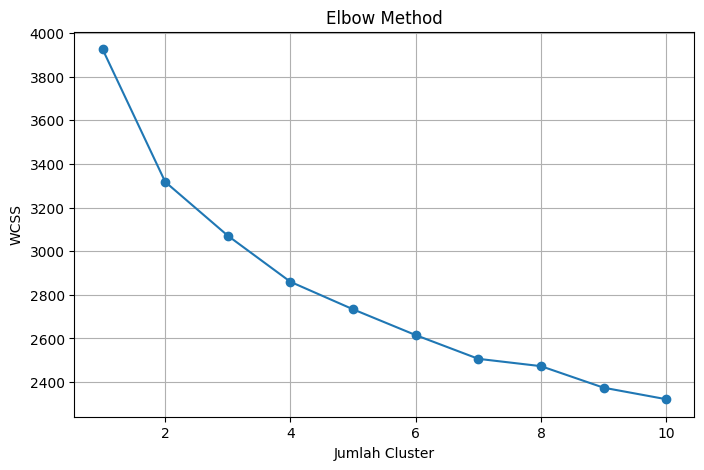

In [46]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Jumlah Cluster")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [48]:
# ==========================================
# MEMBANGUN MODEL K-MEANS
# ==========================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster = kmeans.fit_predict(X_scaled)

In [49]:
df_cluster = df.copy()

df_cluster["Cluster"] = cluster

df_cluster.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Cluster
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,1
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,2
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,1


In [50]:
print(df_cluster["Cluster"].value_counts())

Cluster
0    163
2     95
1     44
Name: count, dtype: int64


In [51]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    cluster
)

print("Silhouette Score :", round(silhouette,3))

Silhouette Score : 0.165


In [52]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(
    X_scaled,
    cluster
)

print("Davies Bouldin Index :", round(dbi,3))

Davies Bouldin Index : 2.044


In [53]:
# ==========================================
# PCA
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_component = pca.fit_transform(X_scaled)

principal_df = pd.DataFrame(
    principal_component,
    columns=["PC1","PC2"]
)

principal_df["Cluster"] = cluster

principal_df.head()

,PC1,PC2,Cluster
0,-0.403727,-1.152038,0
1,2.614955,-0.600532,1
2,3.110398,-1.303946,2
3,-0.392439,-0.322416,0
4,2.255588,1.971414,1


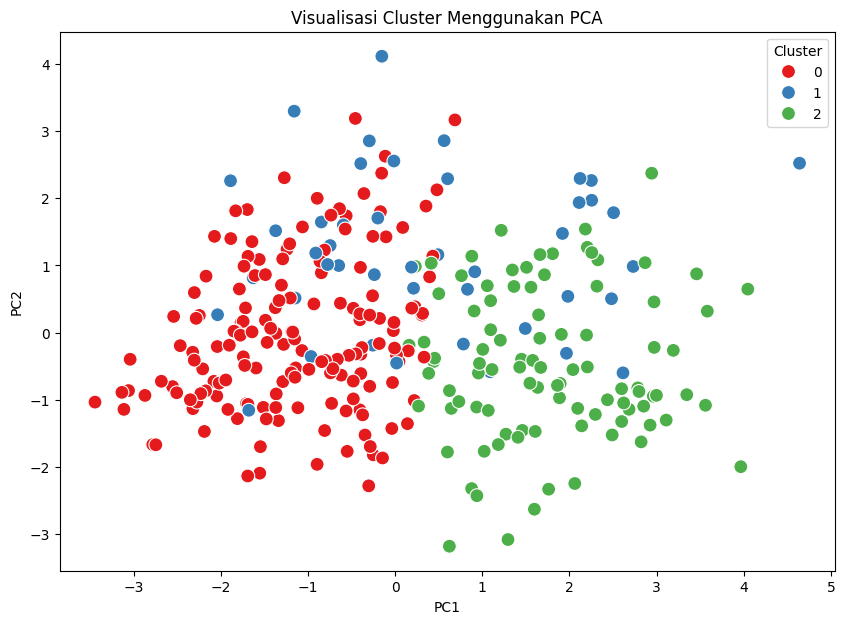

In [54]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=principal_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Visualisasi Cluster Menggunakan PCA")

plt.show()

In [55]:
centroid = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_cluster.columns
)

centroid

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.358975,-0.107843,0.261617,-0.149132,-0.036037,-0.418446,0.095585,0.530485,-0.463096,-0.434472,0.441056,-0.360882,-0.183192
1,0.288077,0.096968,0.255933,0.437433,0.011877,2.389793,-0.180274,0.028765,0.027895,0.000117,-0.091738,0.370484,-0.105504
2,0.482501,0.140124,-0.567417,0.053278,0.056332,-0.388886,-0.080509,-0.923524,0.781656,0.745409,-0.714269,0.447604,0.363185


In [56]:
cluster_summary = df_cluster.groupby("Cluster").mean()

cluster_summary

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
Cluster,,,,,,,,,,,,,,
0,51.177914,0.631902,1.233129,128.987730,244.638037,0.000000,0.576687,161.699387,0.110429,0.539264,1.668712,0.355828,2.202454,0.760736
1,57.022727,0.727273,1.227273,139.272727,247.113636,1.000000,0.431818,150.227273,0.340909,1.043182,1.340909,1.090909,2.250000,0.522727
2,58.778947,0.747368,0.378947,132.536842,249.410526,0.010526,0.484211,128.452632,0.694737,1.907368,0.957895,1.168421,2.536842,0.178947


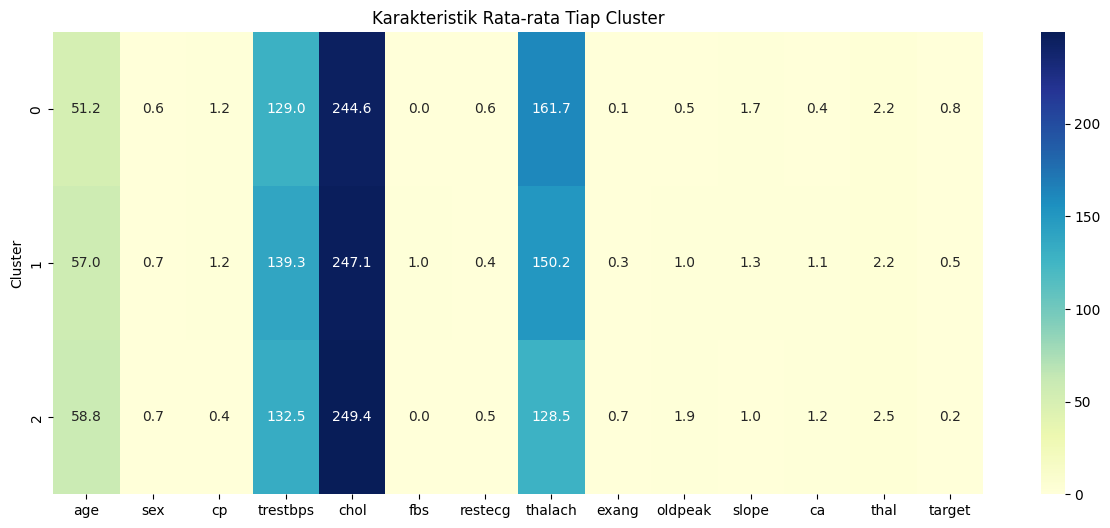

In [57]:
plt.figure(figsize=(15,6))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f"
)

plt.title("Karakteristik Rata-rata Tiap Cluster")

plt.show()

In [58]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["target"]
)

target,0,1
Cluster,,
0,39,124
1,21,23
2,78,17


# Kesimpulan Unsupervised Learning

Berdasarkan Elbow Method dipilih jumlah cluster sebanyak 3.

Model K-Means berhasil mengelompokkan pasien ke dalam tiga kelompok berdasarkan karakteristik kesehatan seperti usia, tekanan darah, kolesterol, denyut jantung maksimum, dan fitur lainnya.

Evaluasi menggunakan Silhouette Score menunjukkan kualitas cluster yang cukup baik, sedangkan Davies-Bouldin Index menunjukkan tingkat pemisahan antar cluster yang baik.

Visualisasi menggunakan PCA memperlihatkan bahwa sebagian besar cluster dapat dipisahkan dengan cukup jelas.

Hasil analisis rata-rata setiap cluster menunjukkan bahwa masing-masing cluster memiliki karakteristik kesehatan yang berbeda sehingga dapat digunakan sebagai dasar segmentasi pasien berdasarkan profil kesehatannya.